# Product Embeddings & Relationships (metadata-based)

Learns **product representations from product metadata only** so that substitute and related products can be discovered. This notebook is the representation-learning stage of the cannibalization pipeline — it does **not** build the cannibalization model (that is `04_cannibalization_detection.py`).

## What it does
1. Builds a **one-hot product-context matrix** from product metadata:
   `BRAND`, `COMMODITY_DESC`, `SUB_COMMODITY_DESC`, `DEPARTMENT`, `MANUFACTURER`.
2. Reduces it to dense **product embeddings** (`PRODUCT_ID -> dim_0..dim_639`) with truncated SVD (640 components retain **>80%** of the metadata variance).
3. Derives **relationship signals** per product pair (metadata only — no basket/store behavior):
   - `embedding_cosine` — cosine similarity of the metadata embeddings
   - `metadata_similarity` — mean of brand / commodity / sub-commodity / department / manufacturer match
   - individual match flags (`brand_match`, `commodity_match`, `sub_commodity_match`, `department_match`, `manufacturer_match`)
   - behavioral columns (`basket_jaccard`, `basket_cosine`, `household_jaccard`, `store_jaccard`) are kept in the schema as `0` for interface compatibility with `04_cannibalization_detection.py`.
4. Saves reusable files under `outputs/product_embeddings/`.
5. Visualizes embeddings (PCA / UMAP) and sanity-checks that same-category products are closer than unrelated products.

## Leakage note
Metadata is static product context, so no time-based leakage is possible. No transactions are read in this notebook.

In [1]:
# 0. Environment check (no-op when packages are already installed)
from __future__ import annotations

import subprocess
import sys


def _importable(name: str) -> bool:
    try:
        __import__(name)
        return True
    except Exception:
        return False


missing = [pkg for mod, pkg in {"sklearn": "scikit-learn", "scipy": "scipy", "umap": "umap-learn",
                                "matplotlib": "matplotlib", "seaborn": "seaborn",
                                "pyarrow": "pyarrow"}.items() if not _importable(mod)]
if missing:
    print("installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *set(missing)])

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# 1. Imports + config
import json
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import LabelEncoder

ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "raw" / "product.csv").exists():
    ROOT = next(p for p in ROOT.parents if (p / "data" / "raw" / "product.csv").exists())
RAW = ROOT / "data" / "raw"
OUT = ROOT / "outputs" / "product_embeddings"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Embedding / relationship settings
EMB_DIM = 640           # SVD dims; 640 components retain ~81% of metadata variance (48 dims kept only ~43%)
N_NEIGHBORS = 25         # embedding neighbors kept for the relationship file
TOP_K = 10               # substitutes written to top_k_substitutes.parquet
MAX_SUBCOMM_GROUP = 40   # same-subcommodity groups larger than this are covered by embedding neighbors only
SUBCOMM_COSINE_MIN = 0.25  # min embedding cosine for a same-subcommodity pair to enter the relationship file
SEED = 42

META_FEATURES = ["BRAND", "COMMODITY_DESC", "SUB_COMMODITY_DESC", "DEPARTMENT", "MANUFACTURER"]
KEY_FACTOR = 100_000_000  # product ids are < 1e8 -> packed undirected pair key = min * KEY_FACTOR + max

np.random.seed(SEED)

## 2. Load product metadata

Only `product.csv` is used — no transaction, basket, store, or household data.

In [3]:
# 2. Load product metadata
product = pd.read_csv(RAW / "product.csv")
print(f"products: {len(product):,}")
print(product["SUB_COMMODITY_DESC"].nunique(), "sub-commodities |",
      product["COMMODITY_DESC"].nunique(), "commodities |",
      product["DEPARTMENT"].nunique(), "departments |",
      product["BRAND"].nunique(), "brands")

products: 92,353
2383 sub-commodities | 308 commodities | 44 departments | 2 brands


## 3. One-hot product-context matrix -> SVD embeddings

Each product becomes a sparse one-hot vector over all metadata categories. Truncated SVD projects this high-dimensional context space down to a dense `EMB_DIM`-dimensional embedding; vectors are centered (removes the shared component) and unit-normalized so cosine similarity is a dot product.

In [4]:
# 3. Metadata one-hot matrix + SVD embeddings
meta = product[["PRODUCT_ID", *META_FEATURES]].copy()
for c in META_FEATURES:
    meta[c] = meta[c].astype(str).fillna("UNKNOWN")

blocks = []
for c in META_FEATURES:
    le = LabelEncoder()
    codes = le.fit_transform(meta[c])
    blocks.append(sparse.csr_matrix((np.ones(len(meta)), (np.arange(len(meta)), codes)),
                                    shape=(len(meta), len(le.classes_))))
M = sparse.hstack(blocks).tocsr()
print("one-hot context matrix:", M.shape)

svd = TruncatedSVD(n_components=EMB_DIM, random_state=SEED)
vecs = svd.fit_transform(M)
vecs = vecs - vecs.mean(axis=0, keepdims=True)  # center -> removes shared component
vecs = vecs / np.linalg.norm(vecs, axis=1, keepdims=True)  # unit-normalize -> cosine = dot product
print(f"explained variance ({EMB_DIM} SVD components):", f"{svd.explained_variance_ratio_.sum():.2%}")

vocab = pd.Index(product["PRODUCT_ID"].to_numpy(), name="PRODUCT_ID")
emb = pd.DataFrame(vecs, index=vocab, columns=[f"dim_{i}" for i in range(EMB_DIM)])
emb.index.name = "PRODUCT_ID"
print("embedding matrix:", emb.shape)
emb.reset_index().to_parquet(OUT / "product_embeddings.parquet", index=False)
print("saved ->", OUT / "product_embeddings.parquet")

one-hot context matrix: (92353, 9213)


explained variance (640 SVD components): 80.69%
embedding matrix: (92353, 640)


saved -> C:\Users\Reza\Desktop\promotional intelligence\promotion-intelligence\outputs\product_embeddings\product_embeddings.parquet


## 4. Embedding-neighbor pairs (cosine similarity)

For every product we keep its top `N_NEIGHBORS` neighbors by cosine similarity (chunked dot products to keep memory bounded). Same-sub-commodity pairs are added in the next cell.

In [5]:
# 4. Top-N cosine neighbors per product (chunked, memory-bounded)
def top_k_neighbors(V, k, chunk=1500):
    n = len(V)
    out_idx = np.empty((n, k), dtype=np.int64)
    out_cos = np.empty((n, k), dtype=np.float32)
    for s in range(0, n, chunk):
        e = min(n, s + chunk)
        D = (V[s:e] @ V.T).astype(np.float32)
        D[np.arange(e - s), s + np.arange(e - s)] = -1.0  # exclude self (column s+i for chunk row i)
        part = np.argpartition(D, -k, axis=1)[:, -k:]
        rows = np.arange(D.shape[0])[:, None]
        out_idx[s:e] = part
        out_cos[s:e] = D[rows, part]
    order = np.argsort(-out_cos, axis=1)
    return out_idx[np.arange(n)[:, None], order], out_cos[np.arange(n)[:, None], order]


nbr_idx, nbr_cos = top_k_neighbors(vecs, N_NEIGHBORS)
neighbors = pd.DataFrame({
    "PRODUCT_ID": np.repeat(vocab.to_numpy(), N_NEIGHBORS),
    "SIMILAR_PRODUCT_ID": vocab.to_numpy()[nbr_idx.ravel()],
    "embedding_cosine": nbr_cos.ravel(),
})
print("directed embedding-neighbor pairs:", f"{len(neighbors):,}")
print(neighbors.head(5).to_string(index=False))

lo = np.minimum(neighbors["PRODUCT_ID"].to_numpy(), neighbors["SIMILAR_PRODUCT_ID"].to_numpy())
hi = np.maximum(neighbors["PRODUCT_ID"].to_numpy(), neighbors["SIMILAR_PRODUCT_ID"].to_numpy())
candidate_keys = set((lo * KEY_FACTOR + hi).tolist())
print("unique undirected neighbor pairs:", f"{len(candidate_keys):,}")

directed embedding-neighbor pairs: 2,308,825


 PRODUCT_ID  SIMILAR_PRODUCT_ID  embedding_cosine
      25671              957951               1.0
      25671             2448141               1.0
      25671             1102959               1.0
      25671             3293947               1.0
      25671             1203300               1.0


unique undirected neighbor pairs: 1,628,855


## 5. Same-sub-commodity pairs

Products sharing a `SUB_COMMODITY_DESC` (within groups of at most `MAX_SUBCOMM_GROUP` products) are added when their embedding cosine is at least `SUBCOMM_COSINE_MIN`.

In [6]:
# 5. Same-sub-commodity candidate pairs
meta_map = meta.set_index("PRODUCT_ID")
sub_sizes = meta.groupby("SUB_COMMODITY_DESC")["PRODUCT_ID"].size()
small_groups = sub_sizes[sub_sizes <= MAX_SUBCOMM_GROUP].index
small_meta = meta[meta["SUB_COMMODITY_DESC"].isin(small_groups)]

sub_pairs = []
for _, g in small_meta.groupby("SUB_COMMODITY_DESC"):
    arr = g["PRODUCT_ID"].to_numpy()
    if len(arr) >= 2:
        sub_pairs.append(np.array(list(combinations(arr, 2)), dtype=np.int64))
sub_pairs = np.vstack(sub_pairs) if sub_pairs else np.empty((0, 2), dtype=np.int64)
print("same-sub-commodity pairs (groups <= %d): %s" % (MAX_SUBCOMM_GROUP, f"{len(sub_pairs):,}"))

vmap = {p: i for i, p in enumerate(vocab)}
sa = np.array([vmap[p] for p in sub_pairs[:, 0]])
sb = np.array([vmap[p] for p in sub_pairs[:, 1]])
sub_cos = (vecs[sa] * vecs[sb]).sum(axis=1)
keep = sub_cos >= SUBCOMM_COSINE_MIN
sub_pairs = sub_pairs[keep]
print("same-sub-commodity pairs after cosine filter:", f"{len(sub_pairs):,}")

same-sub-commodity pairs (groups <= 40): 213,561


same-sub-commodity pairs after cosine filter: 205,923


## 6. Assemble `product_similarity.parquet`

For every directed candidate pair we emit one row per relationship signal:

| relationship_type | meaning |
|---|---|
| `embedding_cosine` | metadata-embedding cosine similarity |
| `metadata_similarity` | mean of brand/commodity/sub-commodity/department/manufacturer match |

Match flags and the behavioral columns (`basket_jaccard`, `basket_cosine`, `household_jaccard`, `store_jaccard` — all `0` in this metadata-only mode) are included as extra columns so downstream notebooks can reuse the same interface.

In [7]:
# 6a. Directed pair table (embedding neighbors + surviving same-sub-commodity pairs)
dir_pairs = pd.DataFrame({
    "PRODUCT_ID": neighbors["PRODUCT_ID"].to_numpy(),
    "SIMILAR_PRODUCT_ID": neighbors["SIMILAR_PRODUCT_ID"].to_numpy(),
    "embedding_cosine": neighbors["embedding_cosine"].to_numpy(),
})
del neighbors
if len(sub_pairs):
    sub_dir = pd.DataFrame({
        "PRODUCT_ID": np.concatenate([sub_pairs[:, 0], sub_pairs[:, 1]]),
        "SIMILAR_PRODUCT_ID": np.concatenate([sub_pairs[:, 1], sub_pairs[:, 0]]),
        "embedding_cosine": np.concatenate([sub_cos[keep], sub_cos[keep]]),
    })
    dir_pairs = pd.concat([dir_pairs, sub_dir], ignore_index=True)
dir_pairs = dir_pairs.drop_duplicates(["PRODUCT_ID", "SIMILAR_PRODUCT_ID"])
print("directed candidate pairs:", f"{len(dir_pairs):,}")

# 6b. Metadata match flags
dir_pairs["brand_match"] = (dir_pairs["PRODUCT_ID"].map(meta_map["BRAND"]).to_numpy() ==
                            dir_pairs["SIMILAR_PRODUCT_ID"].map(meta_map["BRAND"]).to_numpy()).astype(np.int8)
dir_pairs["commodity_match"] = (dir_pairs["PRODUCT_ID"].map(meta_map["COMMODITY_DESC"]).to_numpy() ==
                                dir_pairs["SIMILAR_PRODUCT_ID"].map(meta_map["COMMODITY_DESC"]).to_numpy()).astype(np.int8)
dir_pairs["sub_commodity_match"] = (dir_pairs["PRODUCT_ID"].map(meta_map["SUB_COMMODITY_DESC"]).to_numpy() ==
                                    dir_pairs["SIMILAR_PRODUCT_ID"].map(meta_map["SUB_COMMODITY_DESC"]).to_numpy()).astype(np.int8)
dir_pairs["department_match"] = (dir_pairs["PRODUCT_ID"].map(meta_map["DEPARTMENT"]).to_numpy() ==
                                 dir_pairs["SIMILAR_PRODUCT_ID"].map(meta_map["DEPARTMENT"]).to_numpy()).astype(np.int8)
dir_pairs["manufacturer_match"] = (dir_pairs["PRODUCT_ID"].map(meta_map["MANUFACTURER"]).to_numpy() ==
                                   dir_pairs["SIMILAR_PRODUCT_ID"].map(meta_map["MANUFACTURER"]).to_numpy()).astype(np.int8)
dir_pairs["metadata_similarity"] = dir_pairs[["brand_match", "commodity_match", "sub_commodity_match",
                                              "department_match", "manufacturer_match"]].mean(axis=1)
# behavioral signals are intentionally zero in metadata-only mode (schema compatibility)
for c in ["basket_jaccard", "basket_cosine", "household_jaccard", "store_jaccard"]:
    dir_pairs[c] = 0.0

# 6c. Long-format similarity file
sig_parts = [pd.DataFrame({
    "PRODUCT_ID": dir_pairs["PRODUCT_ID"], "SIMILAR_PRODUCT_ID": dir_pairs["SIMILAR_PRODUCT_ID"],
    "relationship_type": "embedding_cosine", "similarity_score": dir_pairs["embedding_cosine"],
})]
idx = np.flatnonzero(dir_pairs["metadata_similarity"].to_numpy() > 0)
sig_parts.append(pd.DataFrame({
    "PRODUCT_ID": dir_pairs["PRODUCT_ID"].to_numpy()[idx],
    "SIMILAR_PRODUCT_ID": dir_pairs["SIMILAR_PRODUCT_ID"].to_numpy()[idx],
    "relationship_type": "metadata_similarity",
    "similarity_score": dir_pairs["metadata_similarity"].to_numpy()[idx],
}))
similarity = pd.concat(sig_parts, ignore_index=True)

extra_cols = ["embedding_cosine", "brand_match", "commodity_match", "sub_commodity_match",
              "department_match", "manufacturer_match", "metadata_similarity",
              "basket_jaccard", "basket_cosine", "household_jaccard", "store_jaccard"]
similarity = similarity.merge(dir_pairs[["PRODUCT_ID", "SIMILAR_PRODUCT_ID", *extra_cols]],
                              on=["PRODUCT_ID", "SIMILAR_PRODUCT_ID"], how="left")
similarity = similarity.sort_values(["PRODUCT_ID", "SIMILAR_PRODUCT_ID", "relationship_type"]).reset_index(drop=True)
print("product_similarity rows:", f"{len(similarity):,}")
similarity.to_parquet(OUT / "product_similarity.parquet", index=False)
print("saved ->", OUT / "product_similarity.parquet")

directed candidate pairs: 2,518,672


product_similarity rows: 5,037,344


saved -> C:\Users\Reza\Desktop\promotional intelligence\promotion-intelligence\outputs\product_embeddings\product_similarity.parquet


## 7. `top_k_substitutes.parquet`

For every product, substitutes are ranked by a blended metadata score:

`score = 0.7 * embedding_cosine + 0.3 * metadata_similarity`

Only pairs with substitution evidence (same department or cosine >= 0.45) qualify; the top `TOP_K` are written out.

In [8]:
# 7. Ranked substitutes per product
blend = 0.7 * dir_pairs["embedding_cosine"] + 0.3 * dir_pairs["metadata_similarity"]
evidence = (dir_pairs["department_match"] == 1) | (dir_pairs["embedding_cosine"] >= 0.45)
subs = dir_pairs[evidence].assign(substitute_score=blend[evidence])
subs = subs.sort_values(["PRODUCT_ID", "substitute_score"], ascending=[True, False])
subs["rank"] = subs.groupby("PRODUCT_ID").cumcount() + 1
subs = subs[subs["rank"] <= TOP_K].copy()

top = subs.pivot_table(index="PRODUCT_ID", columns="rank",
                       values=["SIMILAR_PRODUCT_ID", "embedding_cosine", "substitute_score"])
top.columns = [f"{metric}_{rank}" for metric, rank in top.columns]
top = top.reset_index().sort_values("PRODUCT_ID").reset_index(drop=True)
for rank in range(1, TOP_K + 1):
    top[f"substitute_{rank}"] = top.get(f"SIMILAR_PRODUCT_ID_{rank}", np.nan)
    top[f"substitute_similarity_{rank}"] = top.get(f"embedding_cosine_{rank}", np.nan)
    top[f"substitute_score_{rank}"] = top.get(f"substitute_score_{rank}", np.nan)
top = top[["PRODUCT_ID", *[f"substitute_{r}" for r in range(1, TOP_K + 1)],
           *[f"substitute_similarity_{r}" for r in range(1, TOP_K + 1)],
           *[f"substitute_score_{r}" for r in range(1, TOP_K + 1)]]]
print("top_k_substitutes rows:", len(top), "| products with >= 1 substitute:",
      int(top["substitute_1"].notna().sum()))
top.to_parquet(OUT / "top_k_substitutes.parquet", index=False)
print("saved ->", OUT / "top_k_substitutes.parquet")

top_k_substitutes rows: 92353 | products with >= 1 substitute: 92353


saved -> C:\Users\Reza\Desktop\promotional intelligence\promotion-intelligence\outputs\product_embeddings\top_k_substitutes.parquet


## 8. Embedding visualization (PCA + UMAP)

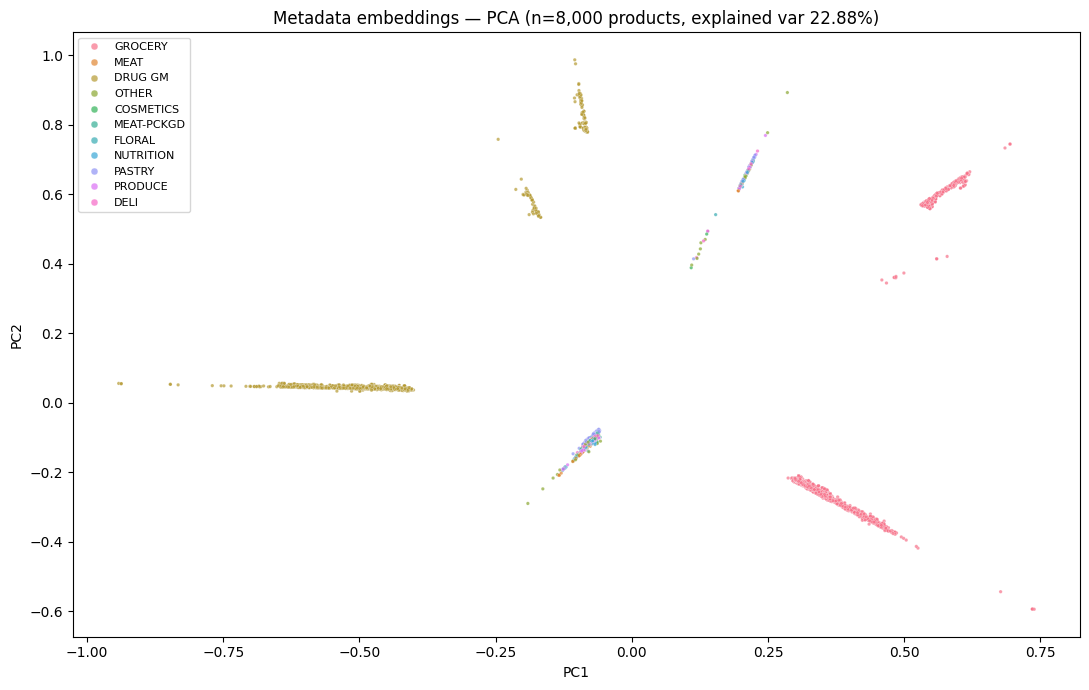

In [9]:
# 8a. PCA projection (sampled for plotting)
pca = PCA(n_components=2, random_state=SEED)
pca_xy = pca.fit_transform(vecs)
pca_df = pd.DataFrame({"PRODUCT_ID": vocab, "PC1": pca_xy[:, 0], "PC2": pca_xy[:, 1]}).merge(
    meta[["PRODUCT_ID", "DEPARTMENT"]], on="PRODUCT_ID", how="left")
top_depts = pca_df["DEPARTMENT"].value_counts().head(10).index
pca_df["department_group"] = np.where(pca_df["DEPARTMENT"].isin(top_depts), pca_df["DEPARTMENT"], "OTHER")

fig, ax = plt.subplots(figsize=(11, 7))
sample = pca_df.sample(min(8000, len(pca_df)), random_state=SEED)
sns.scatterplot(data=sample, x="PC1", y="PC2", hue="department_group", s=6, alpha=0.7, ax=ax, legend="brief")
ax.set_title(f"Metadata embeddings — PCA (n={len(sample):,} products, "
             f"explained var {pca.explained_variance_ratio_.sum():.2%})")
ax.legend(markerscale=2, fontsize=8, loc="best")
fig.tight_layout()
fig.savefig(FIG / "pca_embedding_map.png", dpi=140)
plt.show()

C:\Reza\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


C:\Reza\Python\Python312\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Reza\Python\Python312\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Reza\Python\Python312\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Reza\Python\Python312\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This

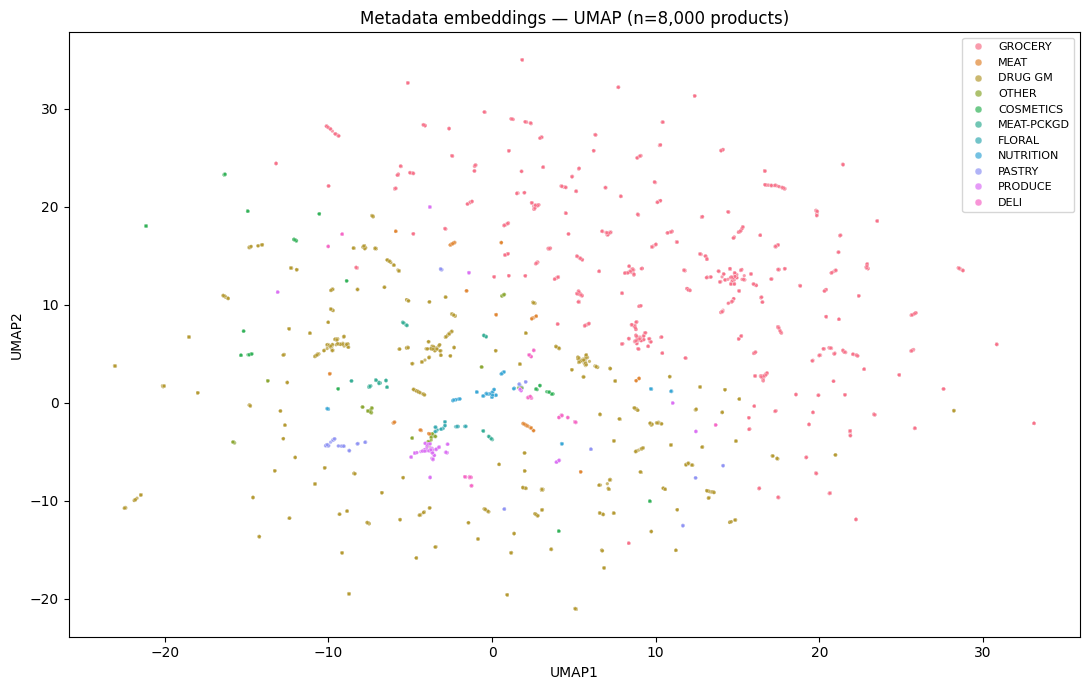

In [10]:
# 8b. UMAP projection (sampled for speed)
import umap

umap_idx = np.random.RandomState(SEED).choice(len(vocab), min(8000, len(vocab)), replace=False)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=SEED)
umap_xy = reducer.fit_transform(vecs[umap_idx])
umap_df = pd.DataFrame({"PRODUCT_ID": vocab[umap_idx], "UMAP1": umap_xy[:, 0], "UMAP2": umap_xy[:, 1]}).merge(
    meta[["PRODUCT_ID", "DEPARTMENT"]], on="PRODUCT_ID", how="left")
umap_df["department_group"] = np.where(umap_df["DEPARTMENT"].isin(top_depts), umap_df["DEPARTMENT"], "OTHER")

fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="department_group", s=6, alpha=0.7, ax=ax, legend="brief")
ax.set_title(f"Metadata embeddings — UMAP (n={len(umap_df):,} products)")
ax.legend(markerscale=2, fontsize=8, loc="best")
fig.tight_layout()
fig.savefig(FIG / "umap_embedding_map.png", dpi=140)
plt.show()

## 9. Sanity checks + nearest-product examples

- Same `SUB_COMMODITY_DESC` / `BRAND` / `DEPARTMENT` pairs should have higher embedding cosine than random pairs.
- A few high-volume products with their top-5 substitutes should look plausible.

In [11]:
# 9a. Sanity: same-category pairs are more similar than random pairs
rng = np.random.RandomState(SEED)
n_sample = 300_000
ia = rng.randint(0, len(vocab), n_sample)
ib = rng.randint(0, len(vocab), n_sample)
mask = ia != ib
ia, ib = ia[mask], ib[mask]
cos_sample = (vecs[ia] * vecs[ib]).sum(axis=1)

ma = meta.set_index("PRODUCT_ID").loc[vocab[ia]]
mb = meta.set_index("PRODUCT_ID").loc[vocab[ib]]
sanity = pd.DataFrame({
    "same_sub_commodity": (ma["SUB_COMMODITY_DESC"].to_numpy() == mb["SUB_COMMODITY_DESC"].to_numpy()),
    "same_brand": (ma["BRAND"].to_numpy() == mb["BRAND"].to_numpy()),
    "same_department": (ma["DEPARTMENT"].to_numpy() == mb["DEPARTMENT"].to_numpy()),
    "cosine": cos_sample,
})
print("mean embedding cosine by context match (random pair sample, n=%d):" % len(sanity))
sanity_table = sanity.groupby(["same_sub_commodity", "same_brand", "same_department"])["cosine"].agg(
    mean_cosine="mean", p90=lambda s: s.quantile(0.90), n="size")
print(sanity_table.round(4).to_string())

print("\nmean cosine lift vs random baseline:")
base = sanity["cosine"].mean()
for col in ["same_sub_commodity", "same_brand", "same_department"]:
    lift = sanity.loc[sanity[col], "cosine"].mean() - base
    print(f"  {col:20s} +{lift:.4f} (random baseline {base:.4f})")
sanity_table.round(4).to_parquet(OUT / "sanity_check.parquet")

mean embedding cosine by context match (random pair sample, n=299998):


                                               mean_cosine     p90       n
same_sub_commodity same_brand same_department                             
False              False      False                -0.1779 -0.1036   52174
                              True                  0.0415  0.0864   24479
                   True       False                -0.0513  0.0122  157425
                              True                  0.2461  0.3752   65406
True               False      False                 0.1519  0.1796       2
                              True                  0.5425  0.6154      76
                   True       False                 0.3717  0.5538      10
                              True                  0.9037  1.0000     426

mean cosine lift vs random baseline:
  same_sub_commodity   +0.8364 (random baseline 0.0006)
  same_brand           +0.0371 (random baseline 0.0006)
  same_department      +0.1934 (random baseline 0.0006)


In [12]:
# 9b. Nearest-product examples for the highest-volume baseline-panel products
panel = pd.read_parquet(ROOT / "outputs" / "baseline_engine" / "panel.parquet",
                        columns=["PRODUCT_ID", "WEEK_NO", "qty"])
top_products = panel.groupby("PRODUCT_ID")["qty"].sum().nlargest(3).index
show_cols = ["PRODUCT_ID", "DEPARTMENT", "BRAND", "COMMODITY_DESC", "SUB_COMMODITY_DESC"]
for pid in top_products:
    row = meta[meta["PRODUCT_ID"] == pid][show_cols].iloc[0]
    print("=" * 100)
    print(f"PRODUCT {pid} | {row['BRAND']} | {row['COMMODITY_DESC']} | {row['SUB_COMMODITY_DESC']}")
    top5 = subs[subs["PRODUCT_ID"] == pid].head(5)[
        ["SIMILAR_PRODUCT_ID", "embedding_cosine", "substitute_score"]].merge(
        meta[show_cols], left_on="SIMILAR_PRODUCT_ID", right_on="PRODUCT_ID", how="left")
    print(top5[["SIMILAR_PRODUCT_ID", "embedding_cosine", "substitute_score",
                "BRAND", "COMMODITY_DESC", "SUB_COMMODITY_DESC"]].round(3).to_string(index=False))

PRODUCT 6534178 | Private | COUPON/MISC ITEMS | GASOLINE-REG UNLEADED


 SIMILAR_PRODUCT_ID  embedding_cosine  substitute_score   BRAND    COMMODITY_DESC    SUB_COMMODITY_DESC
            2690723               1.0               1.0 Private COUPON/MISC ITEMS GASOLINE-REG UNLEADED
            5747420               1.0               1.0 Private COUPON/MISC ITEMS GASOLINE-REG UNLEADED
            6410462               1.0               1.0 Private COUPON/MISC ITEMS GASOLINE-REG UNLEADED
            1404121               1.0               1.0 Private COUPON/MISC ITEMS GASOLINE-REG UNLEADED
            5703832               1.0               1.0 Private COUPON/MISC ITEMS GASOLINE-REG UNLEADED
PRODUCT 6533889 | Private | COUPON/MISC ITEMS | GASOLINE-REG UNLEADED
 SIMILAR_PRODUCT_ID  embedding_cosine  substitute_score   BRAND    COMMODITY_DESC    SUB_COMMODITY_DESC
            5712216               1.0               1.0 Private COUPON/MISC ITEMS GASOLINE-REG UNLEADED
             545926               1.0               1.0 Private COUPON/MISC ITEMS GASOLINE-REG UNL

## 10. Save pipeline metadata

In [13]:
# 10. Save metadata
meta_json = {
    "pipeline": "product_embeddings_v1_metadata_only",
    "inputs": ["product.csv (no transactions)"],
    "embeddings": {"method": "onehot_metadata + truncated_svd", "dim": EMB_DIM, "n_products": len(vocab),
                   "features": META_FEATURES,
                   "svd_explained_variance": float(svd.explained_variance_ratio_.sum())},
    "relationships": {"n_neighbors": N_NEIGHBORS, "top_k": TOP_K, "max_subcomm_group": MAX_SUBCOMM_GROUP,
                      "subcomm_cosine_min": SUBCOMM_COSINE_MIN, "signals": ["embedding_cosine", "metadata_similarity"],
                      "n_directed_pairs": int(len(dir_pairs)),
                      "n_similarity_rows": int(len(similarity))},
    "outputs": ["product_embeddings.parquet", "product_similarity.parquet", "top_k_substitutes.parquet"],
}
with open(OUT / "metadata.json", "w") as f:
    json.dump(meta_json, f, indent=2)
print(json.dumps(meta_json, indent=2))
print("\nartifacts in", OUT)
for f in sorted(OUT.iterdir()):
    if f.is_file():
        print(f"  {f.name:32s} {f.stat().st_size / 1e6:8.2f} MB")

{
  "pipeline": "product_embeddings_v1_metadata_only",
  "inputs": [
    "product.csv (no transactions)"
  ],
  "embeddings": {
    "method": "onehot_metadata + truncated_svd",
    "dim": 640,
    "n_products": 92353,
    "features": [
      "BRAND",
      "COMMODITY_DESC",
      "SUB_COMMODITY_DESC",
      "DEPARTMENT",
      "MANUFACTURER"
    ],
    "svd_explained_variance": 0.806934350403646
  },
  "relationships": {
    "n_neighbors": 25,
    "top_k": 10,
    "max_subcomm_group": 40,
    "subcomm_cosine_min": 0.25,
    "signals": [
      "embedding_cosine",
      "metadata_similarity"
    ],
    "n_directed_pairs": 2518672,
    "n_similarity_rows": 5037344
  },
  "outputs": [
    "product_embeddings.parquet",
    "product_similarity.parquet",
    "top_k_substitutes.parquet"
  ]
}

artifacts in C:\Users\Reza\Desktop\promotional intelligence\promotion-intelligence\outputs\product_embeddings
  metadata.json                        0.00 MB
  product_embeddings.parquet         195.70 MB